# Pre-reqs

In [6]:
!pip install gensim
!pip install bertopic
!pip install bertopic[sentence-transformers]
!pip install pyLDAvis
!pip install spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
zsh:1: no matches found: bertopic[sentence-transformers]

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
zsh:1: command not found: python


In [10]:
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [77]:
import re
import pandas as pd, json
import json, os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

import spacy
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
nlp = spacy.load("en_core_web_sm")

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases, TfidfModel
from gensim.models.phrases import Phraser

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import math

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import MaximalMarginalRelevance
from hdbscan import HDBSCAN
from umap import UMAP
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michelle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data

Source: https://github.com/atharva-naik/brooklyn99-dataset/tree/main/plain-text/season-1

Brief description of dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [15]:
# data_path = "/content/drive/MyDrive/CSDS 601/dataset"

data_path = "brooklyn99-dataset/dataset"

In [16]:
rows = []

for season in sorted(os.listdir(data_path)):

  season_path = os.path.join(data_path, season)
  if not os.path.isdir(season_path):
      continue

  for episode_file in sorted(os.listdir(season_path)):
      episode_path = os.path.join(season_path, episode_file)
      with open(episode_path, "r", encoding="utf-8") as f:
          episode = json.load(f)

      for line in episode:
        rows.append({
            "season": season,
            "episode": episode_file,
            "text": line
        })

df = pd.DataFrame(rows)
print(df.shape)
df

(83621, 3)


,season,episode,text
0,season-1,episode-1-Pilot.json,>This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.
...,...,...,...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.
83619,season-7,episode-9-Dillman.json,Who?


## Helper methods

In [17]:
def create_chunked_corpus(df, chunk_size, text_col='text'):
    chunks = []
    for (season, episode), group in df.groupby(["season", "episode"]):
        lines = group[text_col].tolist()
        for i in range(0, len(lines), chunk_size):
            chunk = " ".join(lines[i:i+chunk_size])
            if len(chunk.split()) > 5:
                chunks.append({
                    "season": season,
                    "episode": episode,
                    "text": chunk
                })
    return pd.DataFrame(chunks)

In [18]:
# building a comprehensive stop_words list

english_stopwords = set(stopwords.words("english"))
b99_stopwords = {
    # character names
    "jake", "peralta", "amy", "santiago", "rosa", "diaz",
    "charles", "boyle", "gina", "linetti", "raymond", "holt",
    "terry", "jeffords", "scully", "hitchcock",
    # dialogue words
    "yeah", "okay", "hey", "uh", "um", "gonna", "wanna",
    "got", "know", "like", "right", "oh", "well", "just",
    "said", "say", "go", "get", "one", "think", "yes",
    "no", "ok", "sure", "wait", "look", "come",
    "want", "need", "mean", "tell", "good", "really"
    # after testing
    "guy", "time", "thing", "man", "way", "little",
    "bad", "day", "people", "fine", "year", "let",
    "cool", "big", "wrong", "real", "new", "nice",
    "lot", "fun", "old", "ill", "thank", "great",
    "sorry", "charle", "first", "possible", "minute",
    "hour", "hell", "weird",
}

stop_words = english_stopwords.union(b99_stopwords)

## Data Cleaning

In [19]:
# Tuple of (pattern, replacement) pairs
clean_patterns = [
    (r"\[.*?\]", ""),    # remove stage directions [giggles]
    (r"\(.*?\)", ""),    # remove stage directions (laughs)
    (r"\b[A-Z]{2,}\b:", ""), # remove character directions e.g. PERALTA:
    (r"♪", ""),          # remove music symbols
    # Subtitle metadata
    # Matches sync/fixed/corrected metadata with separator (&amp; or and)
    (r"(?i)(sync(ed)?|fixed)\s*(&amp;|and)\s*(sync(ed)?|corrections?|corrected).*", ""),
    # Matches sync/fixed metadata without separator (e.g. "Sync corrections by", "Synchronized by")
    (r"(?i)(sync(ed|ronized)?|fixed)\s*(corrections?\s*by|by).*", ""),
    (r"(?i)\s*ripped\s*by\s*\S+.*", ""),
    # Remove the closing credits line
    (r"(?i)-?\s*not a doctor[.,]?\s*-?\s*shh[.!]?.*", ""),
    (r"^>+\s*", ""),    # remove leading > at start of line
]

def clean_text(text):
    for pattern, replacement in clean_patterns:
        text = re.sub(pattern, replacement, text)
    text = text.strip()  # remove leading/trailing whitespace
    return text

# Clean the data
df["clean_text"] = df["text"].apply(clean_text)

# Filter empty lines
df = df[df["clean_text"].str.replace(r"[^\w]", "", regex=True).str.len() > 0]

df

,season,episode,text,clean_text
0,season-1,episode-1-Pilot.json,>This job is eating me alive.,This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.,I'm not becoming like them.
...,...,...,...,...
83615,season-7,episode-9-Dillman.json,Well...,Well...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,","Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.,It's Sergeant Leslie Hunt-Minkoff.


In [20]:
def find_lines_containing(df, search_string, column="text"):
    mask = df[column].str.contains(search_string, case=False, na=False)
    results = df[mask]
    print(f"Found {len(results)} lines containing '{search_string}'")
    return results

find_lines_containing(df, "ripped by")

Found 2 lines containing 'ripped by'


,season,episode,text,clean_text
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...,I spent all these years trying to be the good ...
552,season-1,episode-1-Pilot.json,"Great work, team! Ripped By mstoll","Great work, team!"


In [21]:
df = df[['season', 'episode', 'clean_text']].copy().rename(columns={'clean_text': 'text'})
df

,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive.
1,season-1,episode-1-Pilot.json,I can't breathe anymore.
2,season-1,episode-1-Pilot.json,I spent all these years trying to be the good ...
3,season-1,episode-1-Pilot.json,The man in the white hat.
4,season-1,episode-1-Pilot.json,I'm not becoming like them.
...,...,...,...
83615,season-7,episode-9-Dillman.json,Well...
83616,season-7,episode-9-Dillman.json,"Since Dillman is clearly out of the top spot now,"
83617,season-7,episode-9-Dillman.json,who's the best detective you've ever worked with?
83618,season-7,episode-9-Dillman.json,It's Sergeant Leslie Hunt-Minkoff.


# LDA

For LDA,*

1. Lowercase everything
2. Remove whitespace, punctuation, numbers
3. Tokenize
4. Remove stop words (english stop words, show sepcific words like character names and fillter dialogue words)
5. Lemmatize (keep to roots) vs stemming
6. Filter by token length and frequency, and then filter extremes
7. Build Bag of Words

## Baseline LDA

In [22]:
lda_df = (
    df.groupby(["season", "episode"])["text"]
    .apply(lambda lines: " ".join(lines))
    .reset_index()
)

print(f"Total episodes:", len(lda_df))
lda_df.head()

Total episodes: 134


,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive. I can't breathe a...
1,season-1,episode-10-Thanksgiving.json,- Happy Turkey Day. - Yes! Right out of the ga...
2,season-1,episode-11-Christmas.json,"all right, you take the skinny one on the righ..."
3,season-1,episode-12-Pontiac_Bandit.json,He's here. Boyle's here. This is so fun! I wis...
4,season-1,episode-13-The_Bet.json,"charles, this is exciting. Medal of valor. I k..."


In [23]:
def preprocess_for_lda(text):
  # make lowercase and remove punctuation
  text = text.lower()
  text = re.sub(r"[^a-z\s]", "", text)

  # lemmatize and filter via spaCy
  docs = nlp(text)
  tokens = [
      token.lemma_ for token in docs
      if token.is_alpha # letters only
      and token.lemma_ not in stop_words # and not a stop word
      and len(token.lemma_) > 2 # longer than 2 characters (like to, an, ok)
      and token.lemma_ != "-PRON-" # like he, she, they
  ]
  return tokens

# Preprocess episodes for LDA
lda_docs = [preprocess_for_lda(text) for text in lda_df["text"]]

lda_docs[1][:20]

['happy',
 'turkey',
 'gate',
 'play',
 'bingo',
 'thanksgiving',
 'edition',
 'everyone',
 'fill',
 'card',
 'charlesrelate',
 'scenario',
 'bingo',
 'buck',
 'call',
 'turkey',
 'center',
 'square',
 'explain',
 'eat']

In [24]:
dictionary = corpora.Dictionary(lda_docs)

dictionary.filter_extremes(
  no_below=5, # words must appear in at least 2 episodes
  no_above=0.8, # words can't appear in more than 80% of episodes
  keep_n=10000
)

# convert into bag of words
corpus = [dictionary.doc2bow(doc) for doc in lda_docs]

print(f"Dictionary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

lda_docs[1][:20]

Dictionary size: 3223
Corpus size: 134


['happy',
 'turkey',
 'gate',
 'play',
 'bingo',
 'thanksgiving',
 'edition',
 'everyone',
 'fill',
 'card',
 'charlesrelate',
 'scenario',
 'bingo',
 'buck',
 'call',
 'turkey',
 'center',
 'square',
 'explain',
 'eat']

In [25]:
# training the LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    passes=10,
    random_state=42
)

for idx, topic in lda_model.print_topics(num_words=10):
  print(f"Topic {idx}: {topic}")

Topic 0: 0.005*"room" + 0.005*"detective" + 0.004*"party" + 0.004*"pimento" + 0.003*"run" + 0.003*"whoa" + 0.003*"show" + 0.003*"check" + 0.003*"car" + 0.003*"judy"
Topic 1: 0.008*"boom" + 0.006*"bill" + 0.005*"mom" + 0.004*"dad" + 0.004*"meet" + 0.004*"david" + 0.004*"hello" + 0.004*"whoa" + 0.004*"marry" + 0.003*"party"
Topic 2: 0.007*"baby" + 0.006*"sharon" + 0.006*"figgis" + 0.006*"bob" + 0.006*"wedding" + 0.005*"course" + 0.005*"kill" + 0.005*"phone" + 0.004*"hospital" + 0.004*"greg"
Topic 3: 0.004*"phone" + 0.004*"ninenine" + 0.003*"night" + 0.003*"whoa" + 0.003*"cop" + 0.003*"book" + 0.003*"point" + 0.003*"tonight" + 0.003*"lose" + 0.003*"room"
Topic 4: 0.007*"cop" + 0.005*"party" + 0.005*"question" + 0.005*"night" + 0.004*"solve" + 0.004*"dad" + 0.004*"lie" + 0.004*"kevin" + 0.004*"detective" + 0.004*"truck"
Topic 5: 0.004*"kid" + 0.004*"play" + 0.004*"watch" + 0.004*"cop" + 0.003*"dad" + 0.003*"sarge" + 0.003*"detective" + 0.003*"baby" + 0.003*"listen" + 0.003*"drug"
Topic 6: 

In [26]:
coherence_model = CoherenceModel(
    model=lda_model,
    texts=lda_docs,
    dictionary=dictionary,
    coherence="c_v"
)

print(f"Coherence Score: {coherence_model.get_coherence()}")

Coherence Score: 0.22426732199210514


Topics: 5, Coherence: 0.2485
Topics: 10, Coherence: 0.2229
Topics: 15, Coherence: 0.2766
Topics: 20, Coherence: 0.2941
Topics: 25, Coherence: 0.2662
Topics: 30, Coherence: 0.2627
Topics: 35, Coherence: 0.2550
Topics: 40, Coherence: 0.2577
Topics: 45, Coherence: 0.2610
Topics: 50, Coherence: 0.2690

Optimal Number of Topics: 20
Coherence Score: 0.2941


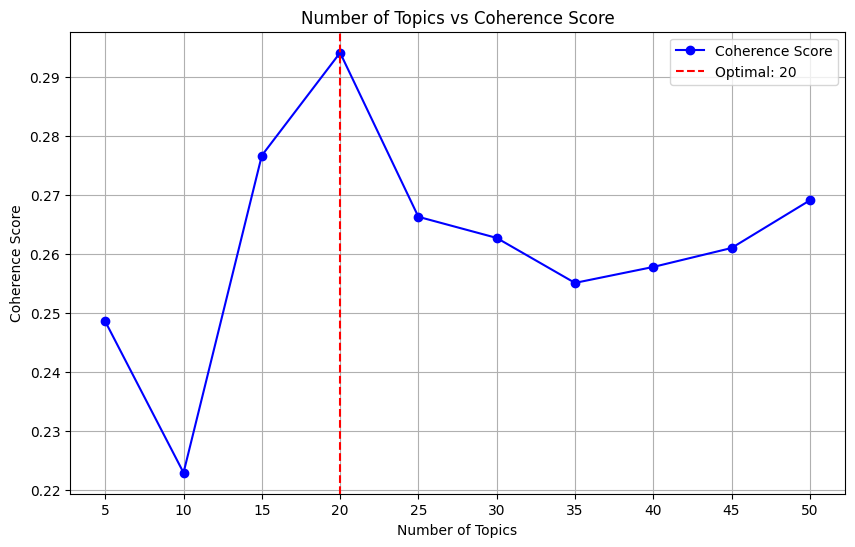

In [27]:
# tuning number of topics and picking the one with the highest coherence

# specify range of topics
min_topics = 5
max_topics = 50
step_size = 5
topics_range = range(min_topics, max_topics + 1, step_size)

# grid search over number of topics
coherence_scores = []

for num_topics in topics_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=15,
        random_state=42
    )
    cm = CoherenceModel(
        model=lda_model,
        texts=lda_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics}, Coherence: {score:.4f}")

# find optimal
optimal_num_topics = list(topics_range)[np.argmax(coherence_scores)]
print(f"\nOptimal Number of Topics: {optimal_num_topics}")
print(f"Coherence Score: {max(coherence_scores):.4f}")

# plot
plt.figure(figsize=(10, 6))
plt.plot(topics_range, coherence_scores, marker="o", color="b", label="Coherence Score")
plt.axvline(x=optimal_num_topics, color="r", linestyle="--", label=f"Optimal: {optimal_num_topics}")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Number of Topics vs Coherence Score")
plt.xticks(topics_range)
plt.legend()
plt.grid(True)
plt.show()

## Enhanced LDA

In [28]:
# chunk by scene since each episode can contain different plot lines
def create_chunked_corpus(df, chunk_size, text_col='text'):
    chunks = []
    for (season, episode), group in df.groupby(["season", "episode"]):
        lines = group[text_col].tolist()
        for i in range(0, len(lines), chunk_size):
            chunk = " ".join(lines[i:i+chunk_size])
            if len(chunk.split()) > 5:
                chunks.append({
                    "season": season,
                    "episode": episode,
                    "text": chunk
                })
    return pd.DataFrame(chunks)

# Create the new enhanced_lda_df
enhanced_lda_df = create_chunked_corpus(df, chunk_size=50)

print(f"Number of chunks: {len(enhanced_lda_df)}")
enhanced_lda_df.head()

Number of chunks: 1704


,season,episode,text
0,season-1,episode-1-Pilot.json,This job is eating me alive. I can't breathe a...
1,season-1,episode-1-Pilot.json,"I will. J.P., update on the Morgenthau murder?..."
2,season-1,episode-1-Pilot.json,What the hell's goin' on around here? Fire ext...
3,season-1,episode-1-Pilot.json,I never liked that nickname. Though to be fair...
4,season-1,episode-1-Pilot.json,That was very well put. I've talked a lot abou...


In [29]:
enhanced_stop_words = stop_words.copy()

def preprocess_for_enhanced_lda(text, stop_words):
    # make lowercase and remove punctuation
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)

    # lemmatize and filter via spaCy — nouns and adjectives only
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha
        and token.lemma_ not in stop_words
        and len(token.lemma_) > 2
        and token.lemma_ != "-PRON-"
        and token.pos_ in ("NOUN", "PROPN", "ADJ")  # restrict to nouns + adjectives
    ]
    return tokens

def use_enhanced_lda(df, stop_words=enhanced_stop_words):

  # Preprocess episodes for enhanced LDA
  enhanced_lda_docs = [preprocess_for_enhanced_lda(text, stop_words) for text in enhanced_lda_df["text"]]

  # Build bigrams
  bigram = Phrases(enhanced_lda_docs, min_count=3, threshold=5)
  bigram_mod = Phraser(bigram)

  # Build trigrams on top of bigrams
  trigram = Phrases(bigram[enhanced_lda_docs], min_count=3, threshold=5)
  trigram_mod = Phraser(trigram)

  # Apply bigrams and trigrams
  enhanced_lda_docs = [trigram_mod[bigram_mod[doc]] for doc in enhanced_lda_docs]

  return enhanced_lda_docs

# Preview
enhanced_lda_docs = use_enhanced_lda(enhanced_lda_df)
print(enhanced_lda_docs[1][:20])



['morgenthau', 'murder', 'news', 'fan', 'morning', 'luxury', 'food', 'importer', 'henry', 'morgenthau', 'body', 'cleaning_lady', 'interview', 'expert', 'detective', 'work', 'gross', 'chin', 'flan_flan', 'butterscotch']


In [31]:
# using tfidif


# build dictionary
enhanced_dictionary = corpora.Dictionary(enhanced_lda_docs)
enhanced_dictionary.filter_extremes(
    no_below=5,
    no_above=0.8,
    keep_n=10000
)

# build raw bow corpus
enhanced_corpus = [enhanced_dictionary.doc2bow(doc) for doc in enhanced_lda_docs]

print(f"Dictionary size: {len(enhanced_dictionary)}")
print(f"Corpus size: {len(enhanced_corpus)}")

# apply TF-IDF model
tfidf = TfidfModel(enhanced_corpus)
enhanced_corpus_tfidf = tfidf[enhanced_corpus]

Dictionary size: 3208
Corpus size: 1704


Topics: 5, Coherence: 0.2596
Topics: 10, Coherence: 0.2613
Topics: 15, Coherence: 0.3382
Topics: 20, Coherence: 0.3768
Topics: 25, Coherence: 0.4334
Topics: 30, Coherence: 0.4813
Topics: 35, Coherence: 0.4532
Topics: 40, Coherence: 0.5118
Topics: 45, Coherence: 0.5232
Topics: 50, Coherence: 0.5267
Topics: 55, Coherence: 0.4750
Topics: 60, Coherence: 0.5072


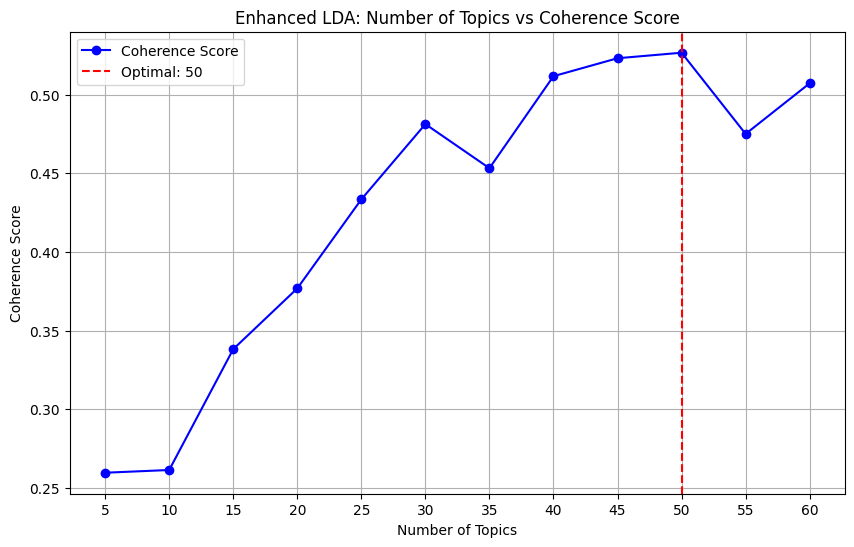

Optimal Number of Topics: 50
Best Coherence Score: 0.5267


In [32]:
# tuning number of topics and picking the one with the highest coherence

coherence_scores = []

# specify range of topics
min_topics = 5
max_topics = 60
step_size = 5
topics_range = range(min_topics, max_topics + 1, step_size)

for num_topics in topics_range:
    lda_model = LdaModel(
        corpus=enhanced_corpus_tfidf,
        id2word=enhanced_dictionary,
        num_topics=num_topics,
        passes=10,
        alpha="auto", # letting the model choose the alpha, eta
        eta="auto",
        random_state=42
    )
    cm = CoherenceModel(
        model=lda_model,
        texts=enhanced_lda_docs,
        dictionary=enhanced_dictionary,
        coherence="c_v"
    )
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics}, Coherence: {score:.4f}")

# Plot
optimal_num_topics_enhanced = list(topics_range)[np.argmax(coherence_scores)]

plt.figure(figsize=(10, 6))
plt.plot(topics_range, coherence_scores, marker="o", color="b", label="Coherence Score")
plt.axvline(x=optimal_num_topics_enhanced, color="r", linestyle="--",
            label=f"Optimal: {optimal_num_topics_enhanced}")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Enhanced LDA: Number of Topics vs Coherence Score")
plt.xticks(topics_range)
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {optimal_num_topics_enhanced}")
print(f"Best Coherence Score: {max(coherence_scores):.4f}")

In [33]:
optimal_num_topics_enhanced = 30

In [34]:
# enhanced LDA model

enhanced_lda_model = LdaModel(
    corpus=enhanced_corpus_tfidf,
    id2word=enhanced_dictionary,
    num_topics=optimal_num_topics_enhanced,
    passes=15,          # more passes for final model
    alpha="auto",
    eta="auto",
    random_state=42
)

# Preview topics
for idx, topic in enhanced_lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

final_coherence = CoherenceModel(
    model=enhanced_lda_model,
    texts=enhanced_lda_docs,
    dictionary=enhanced_dictionary,
    coherence="c_v"
).get_coherence()

print(f"Final Enhanced LDA Coherence: {final_coherence:.4f}")

Topic 18: 0.009*"muffin" + 0.008*"plaque" + 0.005*"chain" + 0.004*"cold_case" + 0.004*"student" + 0.004*"blog" + 0.004*"hawkin" + 0.004*"testicle" + 0.004*"response" + 0.003*"vasectomy"
Topic 27: 0.006*"bread" + 0.005*"curse" + 0.005*"citizen" + 0.005*"dana" + 0.004*"spider" + 0.004*"bean" + 0.004*"wint" + 0.004*"cause" + 0.004*"stranger" + 0.004*"thumb"
Topic 8: 0.006*"break_room" + 0.005*"diaper" + 0.005*"snake" + 0.005*"tail" + 0.004*"mess" + 0.004*"closet" + 0.003*"balloon_arch" + 0.003*"flaco" + 0.003*"john" + 0.003*"saturday"
Topic 29: 0.007*"mmhmm" + 0.005*"miller" + 0.005*"pink" + 0.004*"horny" + 0.004*"thankful" + 0.004*"extreme" + 0.004*"doll" + 0.004*"pontiac_bandit" + 0.004*"hoot" + 0.004*"corkscrew"
Topic 4: 0.006*"switch" + 0.005*"moose" + 0.005*"painting" + 0.004*"gift" + 0.004*"damage" + 0.004*"barrel" + 0.004*"mouse" + 0.004*"ice_cream" + 0.004*"allergy" + 0.004*"rock"
Topic 21: 0.007*"grape" + 0.006*"mother" + 0.005*"cruise" + 0.005*"boat" + 0.004*"getaway" + 0.004*"t

In [35]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    enhanced_lda_model,
    enhanced_corpus_tfidf,
    enhanced_dictionary,
    sort_topics=False
)

pyLDAvis.display(vis)

/Users/michelle/Library/Python/3.12/lib/python/site-packages/dateutil/tz/tz.py:37: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  EPOCH = datetime.datetime.utcfromtimestamp(0)
/Users/michelle/Library/Python/3.12/lib/python/site-packages/dateutil/tz/tz.py:37: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  EPOCH = datetime.datetime.utcfromtimestamp(0)
/Users/michelle/Library/Python/3.12/lib/python/site-packages/dateutil/tz/tz.py:37: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.da

# Bertopic

For Bertopic, the best choice for the document is the use of scenes. Since the dataset does not split the text on scene natively, we experiment with chunking each document with x lines.

## Baseline

### Preprocessing

In [36]:
bertopic_df = df.copy()
bertopic_df.head()

# clean and preprocess text

FILLERS = {'um', 'uh', 'hmm', 'oh', 'ah', 'okay', 'yeah', 'hey', 'like'}

def clean_for_bertopic(text):
    text = text.lower()
    text = re.sub(r"[^\w\s']", '', text)
    tokens = [t for t in text.split() if t not in FILLERS]
    return ' '.join(tokens)

bertopic_df["clean_text"] = bertopic_df["text"].apply(clean_for_bertopic)
bertopic_df = bertopic_df[bertopic_df["clean_text"].str.split().str.len() >= 3].reset_index(drop=True)
bertopic_df.head()

bertopic_df = create_chunked_corpus(bertopic_df, chunk_size=10, text_col='clean_text')
docs = bertopic_df['text'].tolist()
print(f"Total chunks: {len(docs)}")
bertopic_df.head()

Total chunks: 7387


,season,episode,text
0,season-1,episode-1-Pilot.json,this job is eating me alive i can't breathe an...
1,season-1,episode-1-Pilot.json,so the store was hit about two hours ago they ...
2,season-1,episode-1-Pilot.json,watching learning waiting his code name fuzzy ...
3,season-1,episode-1-Pilot.json,it's time to come home i'm not sure if i can i...
4,season-1,episode-1-Pilot.json,i hate this and you're just gonna wanna add on...


### Model

In [37]:


topic_model = BERTopic(
    language="english",
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

2026-05-06 16:07:30,365 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-06 16:07:51,545 - BERTopic - Embedding - Completed ✓
2026-05-06 16:07:51,547 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 16:08:02,095 - BERTopic - Dimensionality - Completed ✓
2026-05-06 16:08:02,096 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 16:08:02,295 - BERTopic - Cluster - Completed ✓
2026-05-06 16:08:02,296 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-06 16:08:02,468 - BERTopic - Representation - Completed ✓
2026-05-06 16:08:02,468 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 16:08:02,477 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 16:08:02,631 - BERTopic - Representation - Completed ✓
2026-05-06 16:08:02,632 - BERTopic - Topic reduction - Reduced number of topics from 78 to 45


### Evaluation

In [38]:
# How many topics were found
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3723,-1_you_the_to_and,"[you, the, to, and, that, it, is, of, in, this]",[come on everyone's tired peralta they just wa...
1,0,1653,0_you_the_to_and,"[you, the, to, and, it, of, that, is, im, in]",[also he set the course record but that's noth...
2,1,349,1_scully_hitchcock_the_and,"[scully, hitchcock, the, and, you, to, it, we,...",[to rosa diaz well you did it but always remem...
3,2,251,2_holt_captain_the_to,"[holt, captain, the, to, you, is, he, him, and...",[yes that actually sounds kind of fun it's gon...
4,3,140,3_rosa_you_her_to,"[rosa, you, her, to, the, that, is, it, no, what]",[it's you're going out of your way to make it ...
5,4,133,4_terry_you_to_the,"[terry, you, to, the, it, im, is, in, and, we]",[maybe it's all in your head bitches be crazy ...
6,5,92,5_dad_mom_my_you,"[dad, mom, my, you, to, your, parents, know, a...",[is my dad here no i called him and he said ho...
7,6,70,6_money_you_we_coin,"[money, you, we, coin, gold, my, the, do, it, ...",[well you owe all of us money so does that mea...
8,7,58,7_boyle_boyles_you_to,"[boyle, boyles, you, to, and, that, it, of, yo...",[happy turkey day yes right out of the gate wh...
9,8,56,8_hacker_server_the_its,"[hacker, server, the, its, it, to, your, in, s...",[right it was transferred in from somewhere we...


In [39]:
# Top words for a specific topic
print(topic_model.get_topic(0))

# How many docs landed in the outlier topic (-1)
outlier_count = sum(t == -1 for t in topics)
total = len(topics)
print(f"Outliers: {outlier_count}/{total} ({outlier_count/total:.1%})")

[('you', 0.017603792869765725), ('the', 0.016982503414921146), ('to', 0.01619798889998855), ('and', 0.013756757625704713), ('it', 0.013405380586598285), ('of', 0.01307713227882578), ('that', 0.01270037630001087), ('is', 0.012588284747657486), ('im', 0.012340736365029992), ('in', 0.011957997052465613)]
Outliers: 3723/7387 (50.4%)


In [40]:
# top words for a specific topic
topic_model.get_topic(0)

[('you', 0.017603792869765725),
 ('the', 0.016982503414921146),
 ('to', 0.01619798889998855),
 ('and', 0.013756757625704713),
 ('it', 0.013405380586598285),
 ('of', 0.01307713227882578),
 ('that', 0.01270037630001087),
 ('is', 0.012588284747657486),
 ('im', 0.012340736365029992),
 ('in', 0.011957997052465613)]

## Enhanced Bertopic

1. curated stopword list
2. restrict to nouns and adjectives
3. better embedding model
4. tune hdbscan
5. add mmr for topic diversity
6. find optimal number of topics
7. fit enhanced model



In [42]:
enhanced_bertopic_df = bertopic_df.copy()
enhanced_bertopic_df

,season,episode,text
0,season-1,episode-1-Pilot.json,this job is eating me alive i can't breathe an...
1,season-1,episode-1-Pilot.json,so the store was hit about two hours ago they ...
2,season-1,episode-1-Pilot.json,watching learning waiting his code name fuzzy ...
3,season-1,episode-1-Pilot.json,it's time to come home i'm not sure if i can i...
4,season-1,episode-1-Pilot.json,i hate this and you're just gonna wanna add on...
...,...,...,...
7382,season-7,episode-9-Dillman.json,thank you for gasping at my gasp sorry you mis...
7383,season-7,episode-9-Dillman.json,as a cleaning lady in college huh i guess ther...
7384,season-7,episode-9-Dillman.json,i stormed into the other room and moped by mys...
7385,season-7,episode-9-Dillman.json,are you kidding i mean just look at today inst...


In [97]:
# only keep nouns & adjectives (parallel to LDA)
nlp.max_length = 3000000

def pos_filter(text):
    doc = nlp(text, disable=['parser', 'ner'])
    tokens = [token.lemma_ for token in doc if token.pos_ in {'NOUN', 'PROPN', 'ADJ'}]
    return ' '.join(tokens)

stop_words_list = list(stop_words)
vectorizer = CountVectorizer(
    stop_words=stop_words_list,
    tokenizer=lambda text: pos_filter(text).split(),
    min_df=2
)

In [98]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    prediction_data=True
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

mmr_model = MaximalMarginalRelevance(diversity=0.3)

topic_model_enhanced = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    representation_model=mmr_model,
    nr_topics='auto',
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [99]:
# fitting the model
topics, probs = topic_model_enhanced.fit_transform(docs)

2026-05-07 06:02:10,074 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-07 06:02:23,712 - BERTopic - Embedding - Completed ✓
2026-05-07 06:02:23,712 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 06:02:25,804 - BERTopic - Dimensionality - Completed ✓
2026-05-07 06:02:25,806 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 06:02:26,032 - BERTopic - Cluster - Completed ✓
2026-05-07 06:02:26,033 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-07 06:02:56,308 - BERTopic - Representation - Completed ✓
2026-05-07 06:02:56,310 - BERTopic - Topic reduction - Reducing number of topics
2026-05-07 06:02:56,329 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 06:03:34,123 - BERTopic - Representation - Completed ✓
2026-05-07 06:03:34,129 - BERTopic - Topic reduction - Reduced number of topics from 77 to 60


In [100]:
print(f"Outliers: {sum(t == -1 for t in topics) / len(topics):.1%} outliers")
topic_model_enhanced.get_topic_info()

Outliers: 53.2% outliers


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3931,-1_cop_bag_sex_kevin,"[cop, bag, sex, kevin, detective, job, night, ...",[the thin blue line just got thick as hell giv...
1,0,1059,0_sergeant_nypd_precinct_arrest,"[sergeant, nypd, precinct, arrest, officer, de...",[i took a seminar and the score is all tied up...
2,1,454,1_earl_fungus_witch_fred,"[earl, fungus, witch, fred, valerie, madeline,...",[all right you've overstepped now bill it's we...
3,2,258,2_captain_armory_museum_jabs,"[captain, armory, museum, jabs, janitor, malda...",[i'm going up to the scene of the shooting and...
4,3,124,3_glitter_claire_suspender_trent,"[glitter, claire, suspender, trent, adrenaline...",[before he went to paraguay damn it i wish the...
5,4,123,4_cliff_veil_twin_cole,"[cliff, veil, twin, cole, balloon, marrow, hel...",[and can't find their way out of it when i was...
6,5,86,5_wedding_venue_married_honeymoon,"[wedding, venue, married, honeymoon, engagemen...",[this wedding looks garbage no no as long as t...
7,6,79,6_mom_father_grease_jerry,"[mom, father, grease, jerry, blessing, daddy, ...",[well you know how our parents have been tende...
8,7,71,7_cheddar_dog_heist_hootsworth,"[cheddar, dog, heist, hootsworth, terri, brace...",[do you hear yes i do that's the jingle of che...
9,8,60,8_cousin_aruba_gobble_bingo,"[cousin, aruba, gobble, bingo, swim, bianca, f...",[my cousin torvald is a hemophiliac and his wi...


In [101]:
results = []
combos = [(mcs, ms) for mcs in [5, 10, 15, 20] for ms in [1, 3, 5]]
total = len(combos)

for i, (min_cluster_size, min_samples) in enumerate(combos, 1):
    print(f"[{i}/{total}] Testing min_cluster_size={min_cluster_size}, min_samples={min_samples}...", end=' ')

    hdbscan_test = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, prediction_data=True)
    test_model = BERTopic(hdbscan_model=hdbscan_test, verbose=False)
    test_topics, _ = test_model.fit_transform(docs)

    outlier_rate = sum(t == -1 for t in test_topics) / len(test_topics)
    n_topics = len(set(test_topics)) - 1
    results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'outlier_rate': round(outlier_rate, 3),
        'n_topics': n_topics
    })
    print(f"done — outlier rate: {outlier_rate:.1%}, topics found: {n_topics}")

print("\nGrid search complete!")
results_df = pd.DataFrame(results).sort_values('outlier_rate')
results_df

[1/12] Testing min_cluster_size=5, min_samples=1... 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

done — outlier rate: 29.0%, topics found: 448
[2/12] Testing min_cluster_size=5, min_samples=3... 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

done — outlier rate: 41.0%, topics found: 304
[3/12] Testing min_cluster_size=5, min_samples=5... 

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

done — outlier rate: 42.9%, topics found: 69
[12/12] Testing min_cluster_size=20, min_samples=5... 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

done — outlier rate: 45.4%, topics found: 52

Grid search complete!


,min_cluster_size,min_samples,outlier_rate,n_topics
0,5,1,0.290,448
3,10,1,0.343,165
6,15,1,0.374,98
1,5,3,0.410,304
4,10,3,0.413,138
9,20,1,0.415,77
10,20,3,0.429,69
7,15,3,0.434,91
11,20,5,0.454,52
2,5,5,0.475,203


In [102]:
# delete once you run LDA
optimal_num_topics_enhanced = 30

In [105]:
min_cluster_size = 15
min_samples = 1

# HDBSCAN with optimal parameters from grid search
hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    prediction_data=True
)


# build the enhanced model with nr_topics matching LDA
topic_model_enhanced = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    representation_model=mmr_model,
    nr_topics=optimal_num_topics_enhanced,
    verbose=True
)

topics, probs = topic_model_enhanced.fit_transform(docs)

outlier_count = sum(t == -1 for t in topics)
print(f"Outliers: {outlier_count}/{len(topics)} ({outlier_count/len(topics):.1%})")
topic_model_enhanced.get_topic_info()

2026-05-07 06:34:39,200 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-07 07:22:23,051 - BERTopic - Embedding - Completed ✓
2026-05-07 07:22:23,088 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 07:22:26,855 - BERTopic - Dimensionality - Completed ✓
2026-05-07 07:22:26,865 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 07:22:27,192 - BERTopic - Cluster - Completed ✓
2026-05-07 07:22:27,193 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-07 07:23:05,397 - BERTopic - Representation - Completed ✓
2026-05-07 07:23:05,400 - BERTopic - Topic reduction - Reducing number of topics
2026-05-07 07:23:05,456 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 07:23:49,165 - BERTopic - Representation - Completed ✓
2026-05-07 07:23:49,185 - BERTopic - Topic reduction - Reduced number of topics from 110 to 30


Outliers: 2916/7387 (39.5%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2916,-1_name_detective_sir_cop,"[name, detective, sir, cop, night, captain, pr...",[i'm hosting a crossword night at the turnkey ...
1,0,620,0_kevin_stevie_judy_cousin,"[kevin, stevie, judy, cousin, doug, bandit, mu...",[so it's not toilet water you're drenched in j...
2,1,441,1_detective_cop_dexter_meth,"[detective, cop, dexter, meth, evidence, murde...",[or just terry gently shutting a window and fo...
3,2,384,2_truck_nypd_airport_toilet,"[truck, nypd, airport, toilet, urine, smell, g...",[name one law and order never heard of it nypd...
4,3,369,3_nucci_debbie_madeline_memorial,"[nucci, debbie, madeline, memorial, jocelyn, b...",[well did you at least text the ninenine and t...
5,4,366,4_wedding_dance_venue_ring,"[wedding, dance, venue, ring, tonight, bachelo...",[so cool cool cool all the pressure's on that ...
6,5,290,5_sergeant_commissioner_officer_precinct,"[sergeant, commissioner, officer, precinct, co...",[sergeant a member of the commissioner selecti...
7,6,261,6_pie_yogurt_pizza_microwave,"[pie, yogurt, pizza, microwave, thanksgiving, ...",[there are several compelling anecdotes the fo...
8,7,256,7_fungus_earl_lemonade_lasagna,"[fungus, earl, lemonade, lasagna, chain, desk,...",[so just normal friend stuff so what's the pla...
9,8,253,8_captain_cheddar_fax_armory,"[captain, cheddar, fax, armory, fanny, candy, ...",[sounds you're bragging but that's just a sad ...


In [111]:
topics, probs = topic_model_enhanced.fit_transform(docs)

outlier_count = sum(t == -1 for t in topics)
print(f"Outliers: {outlier_count}/{len(topics)} ({outlier_count/len(topics):.1%})")
topic_model_enhanced.get_topic_info()

2026-05-07 07:36:18,786 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/231 [00:00<?, ?it/s]

2026-05-07 09:21:06,599 - BERTopic - Embedding - Completed ✓
2026-05-07 09:21:06,615 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 09:21:09,885 - BERTopic - Dimensionality - Completed ✓
2026-05-07 09:21:09,894 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 09:21:10,280 - BERTopic - Cluster - Completed ✓
2026-05-07 09:21:10,281 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-07 09:21:42,010 - BERTopic - Representation - Completed ✓
2026-05-07 09:21:42,012 - BERTopic - Topic reduction - Reducing number of topics
2026-05-07 09:21:42,050 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 09:22:20,789 - BERTopic - Representation - Completed ✓
2026-05-07 09:22:20,806 - BERTopic - Topic reduction - Reduced number of topics from 119 to 30


Outliers: 2815/7387 (38.1%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2815,-1_case_room_sex_name,"[case, room, sex, name, job, phone, idea, desk...",[my stupid mother invited my stupid brother da...
1,0,768,0_detective_nypd_arrest_hacker,"[detective, nypd, arrest, hacker, prison, perp...",[personnel files for the entire squad of cours...
2,1,640,1_cheddar_dog_heist_kevin,"[cheddar, dog, heist, kevin, judy, pedal, brac...",[dogs are my whole life doing work and hanging...
3,2,529,2_sergeant_precinct_kelly_jefford,"[sergeant, precinct, kelly, jefford, ray, inte...",[what's going on i'm here on important busines...
4,3,337,3_nucci_madeline_debbie_app,"[nucci, madeline, debbie, app, sharon, samanth...",[well did you at least text the ninenine and t...
5,4,268,4_wedding_ring_venue_married,"[wedding, ring, venue, married, bride, bachelo...",[this clearly says bach boys no it's batch you...
6,5,235,5_norm_earl_fungus_lemonade,"[norm, earl, fungus, lemonade, pig, mouse, ext...",[guys why are you fighting you're best friends...
7,6,229,6_pregnant_daddy_godfather_casecation,"[pregnant, daddy, godfather, casecation, child...",[point to amy fine you want to know why i real...
8,7,179,7_urine_toilet_pee_santa,"[urine, toilet, pee, santa, smell, ant, fire, ...",[on a random monday with a suspicious message ...
9,8,172,8_breakup_marcus_moo_relationship,"[breakup, marcus, moo, relationship, love, boy...",[is what i'm going with jake i agree with you ...


In [112]:
# calculating coherence

tokenized_docs = [doc.split() for doc in docs]
dictionary = corpora.Dictionary(tokenized_docs)

# extract topic words, excluding the outlier topic (-1)
topic_words = [
    [word for word, _ in topic_model_enhanced.get_topic(t)]
    for t in range(topic_model_enhanced.get_topic_info().shape[0] - 1)
]

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
)

score = coherence_model.get_coherence()
print(f"Coherence Score (c_v): {score:.4f}")

Python(43379) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43381) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43382) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43384) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43385) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Coherence Score (c_v): 0.4310


In [113]:
# coherence model npmi
coherence_model_npmi = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_npmi'
)
print(f"BERTopic c_npmi: {coherence_model_npmi.get_coherence():.4f}")

Python(43387) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43390) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43391) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43392) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43393) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


BERTopic c_npmi: -0.3134


In [114]:
def topic_diversity(topic_words, topk=10):
    unique_words = set()
    total_words = 0
    for words in topic_words:
        unique_words.update(words[:topk])
        total_words += min(len(words), topk)
    return len(unique_words) / total_words

diversity = topic_diversity(topic_words)
print(f"Topic Diversity: {diversity:.4f}")

Topic Diversity: 0.9690


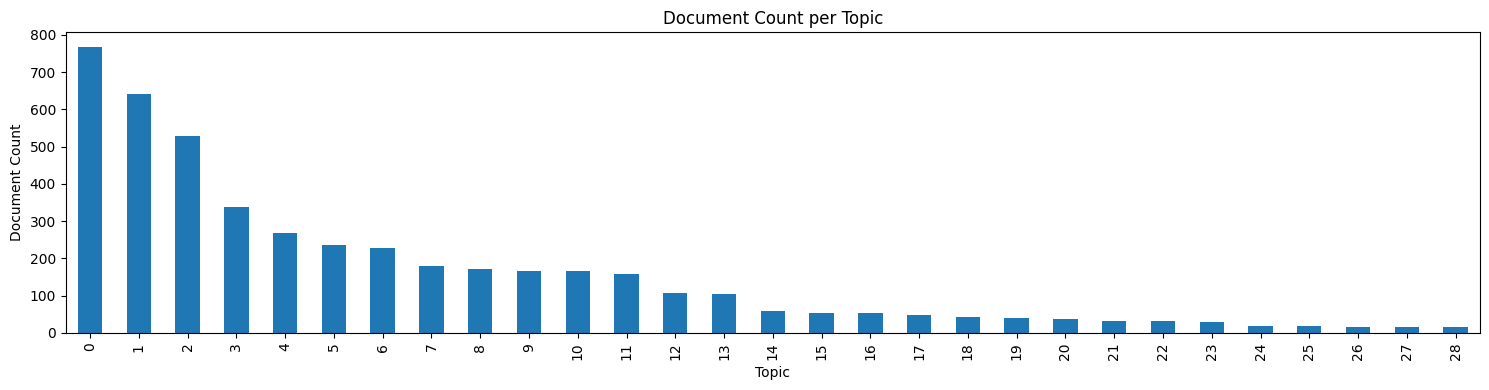

In [115]:
topic_info = topic_model_enhanced.get_topic_info()
topic_info_no_outlier = topic_info[topic_info['Topic'] != -1]

topic_info_no_outlier.plot(
    x='Topic', y='Count', kind='bar', figsize=(15, 4),
    title='Document Count per Topic', legend=False
)
plt.xlabel('Topic')
plt.ylabel('Document Count')
plt.tight_layout()
plt.show()

In [116]:
for topic_id in range(min(30, len(topic_words))):
    words = [w for w, _ in topic_model_enhanced.get_topic(topic_id)][:10]
    print(f"Topic {topic_id}: {', '.join(words)}")

Topic 0: detective, nypd, arrest, hacker, prison, perp, cop, police, hostage, street
Topic 1: cheddar, dog, heist, kevin, judy, pedal, bracelet, bandit, halloween, poker
Topic 2: sergeant, precinct, kelly, jefford, ray, interview, meeting, gay, deputy, email
Topic 3: nucci, madeline, debbie, app, sharon, samantha, bank, kim, funeral, vulture
Topic 4: wedding, ring, venue, married, bride, bachelor, honeymoon, engagement, dinner, invitation
Topic 5: norm, earl, fungus, lemonade, pig, mouse, extinguisher, jar, prank, bathroom
Topic 6: pregnant, daddy, godfather, casecation, childbirth, parenting, anna, fertility, denial, tatum
Topic 7: urine, toilet, pee, santa, smell, ant, fire, turpentine, test, department
Topic 8: breakup, marcus, moo, relationship, love, boyfriend, bisexual, carrie, text, juliet
Topic 9: truck, mattress, coin, tire, investment, minivan, debt, nana, pyramid, bank
Topic 10: yogurt, pie, microwave, thanksgiving, food, sandwich, rice, dish, muffin, recipe
Topic 11: dentis

In [117]:
model = SentenceTransformer('all-MiniLM-L6-v2')

def embedding_coherence(topic_words, model):
    scores = []
    for words in topic_words:
        if len(words) < 2:
            continue
        embeddings = model.encode(words)
        # average pairwise cosine similarity
        sim_matrix = np.inner(embeddings, embeddings)
        n = len(words)
        score = (sim_matrix.sum() - n) / (n * (n - 1))  # exclude diagonal
        scores.append(score)
    return np.mean(scores)

emb_coherence = embedding_coherence(topic_words, embedding_model)
print(f"Embedding Coherence: {emb_coherence:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding Coherence: 0.3042


# Evaluation (LDA vs Bertopic)

In [118]:
# LDA enhanced model
enhanced_lda_model

# Bertopic enhanced model
bertopic_enhanced_model = topic_model_enhanced

tokenized_docs = [doc.split() for doc in docs]
dictionary = corpora.Dictionary(tokenized_docs)

# BERTopic topic words
bertopic_topic_words = [
    [word for word, _ in bertopic_enhanced_model.get_topic(t)]
    for t in range(bertopic_enhanced_model.get_topic_info().shape[0] - 1)
]

# LDA topic words
lda_topic_words = [
    [word for word, _ in enhanced_lda_model.show_topic(t, topn=10)]
    for t in range(enhanced_lda_model.num_topics)
]

# c_v
lda_cv = CoherenceModel(model=enhanced_lda_model, texts=tokenized_docs, dictionary=dictionary, coherence='c_v').get_coherence()
bertopic_cv = CoherenceModel(topics=bertopic_topic_words, texts=tokenized_docs, dictionary=dictionary, coherence='c_v').get_coherence()

# c_npmi
lda_npmi = CoherenceModel(model=enhanced_lda_model, texts=tokenized_docs, dictionary=dictionary, coherence='c_npmi').get_coherence()
bertopic_npmi = CoherenceModel(topics=bertopic_topic_words, texts=tokenized_docs, dictionary=dictionary, coherence='c_npmi').get_coherence()

print(f"{'Metric':<15} {'LDA':>10} {'BERTopic':>10}")
print("-" * 35)
print(f"{'c_v':<15} {lda_cv:>10.4f} {bertopic_cv:>10.4f}")
print(f"{'c_npmi':<15} {lda_npmi:>10.4f} {bertopic_npmi:>10.4f}")

Python(43404) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43406) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43407) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43408) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43409) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43410) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43411) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43412) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43413) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43414) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(43415) Malloc

Metric                 LDA   BERTopic
-----------------------------------
c_v                 0.6749     0.4310
c_npmi             -0.3566    -0.3134


In [119]:
def topic_diversity(topic_words, topk=10):
    unique_words = set()
    total_words = 0
    for words in topic_words:
        unique_words.update(words[:topk])
        total_words += min(len(words), topk)
    return len(unique_words) / total_words

lda_diversity = topic_diversity(lda_topic_words)
bertopic_diversity = topic_diversity(bertopic_topic_words)

print(f"{'Metric':<15} {'LDA':>10} {'BERTopic':>10}")
print("-" * 35)
print(f"{'Diversity':<15} {lda_diversity:>10.4f} {bertopic_diversity:>10.4f}")

Metric                 LDA   BERTopic
-----------------------------------
Diversity           0.9333     0.9690


In [120]:
def embedding_coherence(topic_words, model):
    scores = []
    for words in topic_words:
        if len(words) < 2:
            continue
        embeddings = model.encode(words)
        sim_matrix = np.inner(embeddings, embeddings)
        n = len(words)
        score = (sim_matrix.sum() - n) / (n * (n - 1))
        scores.append(score)
    return np.mean(scores)

lda_emb = embedding_coherence(lda_topic_words, embedding_model)
bertopic_emb = embedding_coherence(bertopic_topic_words, embedding_model)

print(f"{'Metric':<15} {'LDA':>10} {'BERTopic':>10}")
print("-" * 35)
print(f"{'Emb Coherence':<15} {lda_emb:>10.4f} {bertopic_emb:>10.4f}")

Metric                 LDA   BERTopic
-----------------------------------
Emb Coherence       0.2492     0.3042


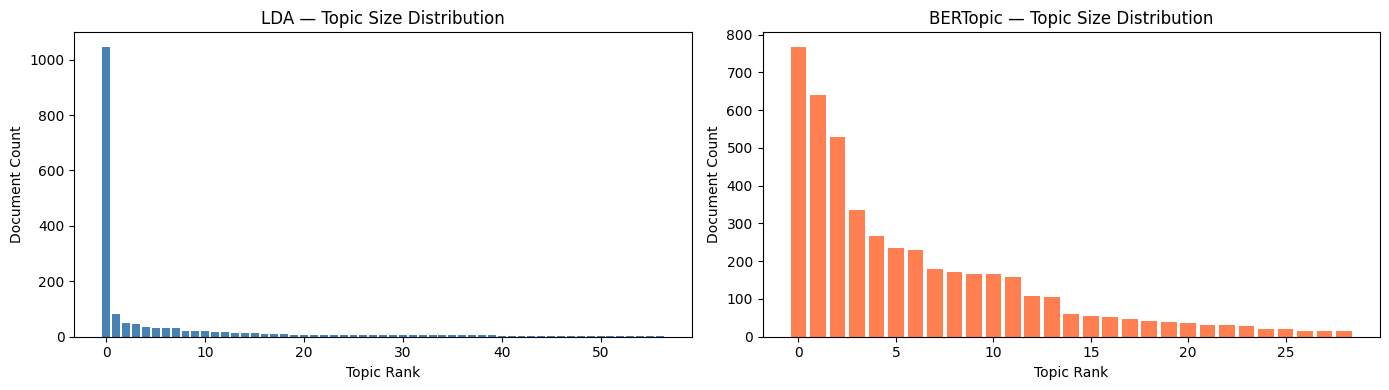

In [121]:
# BERTopic topic sizes
bertopic_info = topic_model_enhanced.get_topic_info()
bertopic_sizes = bertopic_info[bertopic_info['Topic'] != -1]['Count'].values

# LDA topic sizes — count documents per topic
lda_topics_assigned = []
for bow in enhanced_corpus:  
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    top_topic = max(topic_dist, key=lambda x: x[1])[0]
    lda_topics_assigned.append(top_topic)

lda_sizes = pd.Series(lda_topics_assigned).value_counts().sort_index().values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(lda_sizes)), sorted(lda_sizes, reverse=True), color='steelblue')
axes[0].set_title('LDA — Topic Size Distribution')
axes[0].set_xlabel('Topic Rank')
axes[0].set_ylabel('Document Count')

axes[1].bar(range(len(bertopic_sizes)), sorted(bertopic_sizes, reverse=True), color='coral')
axes[1].set_title('BERTopic — Topic Size Distribution')
axes[1].set_xlabel('Topic Rank')
axes[1].set_ylabel('Document Count')

plt.tight_layout()
plt.show()

In [124]:
outlier_rate = outlier_count / len(topics)

print("=" * 45)
print(f"{'Metric':<20} {'LDA':>10} {'BERTopic':>10}")
print("=" * 45)
print(f"{'c_v Coherence':<20} {lda_cv:>10.4f} {bertopic_cv:>10.4f}")
print(f"{'c_npmi Coherence':<20} {lda_npmi:>10.4f} {bertopic_npmi:>10.4f}")
print(f"{'Topic Diversity':<20} {lda_diversity:>10.4f} {bertopic_diversity:>10.4f}")
print(f"{'Emb Coherence':<20} {lda_emb:>10.4f} {bertopic_emb:>10.4f}")
print(f"{'Num Topics':<20} {enhanced_lda_model.num_topics:>10} {len(bertopic_topic_words):>10}")
print(f"{'Outlier Rate':<20} {'n/a':>10} {outlier_rate:>9.1%}")
print("=" * 45)

Metric                      LDA   BERTopic
c_v Coherence            0.6749     0.4310
c_npmi Coherence        -0.3566    -0.3134
Topic Diversity          0.9333     0.9690
Emb Coherence            0.2492     0.3042
Num Topics                   30         29
Outlier Rate                n/a     38.1%
